# 21 — Food Security Analysis (Problem 1) — KPI (LOCKED)

**Business question:** Which countries are becoming food insecure?

**Scope:** 2001–2020, `marts` schema. Built from the earlier exploratory passes.

**Status: LOCKED — re-run confirmed the fix.** Base table rows dropped from 3,973 to
3,413 (560 aggregate rows correctly excluded), `area_code` now maxes at 99 (Zimbabwe) —
no more 5000+ codes anywhere in the output. No errors on execution. This notebook's original aggregate-exclusion
approach (inner-joining to `fact_socioeconomic__population`, described below as
containing "only real countries/territories") was **incorrect**. That population table
also contains ~34 regional/income-group aggregate rows (World, Africa, SIDS, LDCs,
High-income economies, etc. — every genuine aggregate has population data too, since
aggregates are sums), so the join did not actually exclude them. A live diagnostic
against the real DB found 33,756 aggregate rows (area_code >= 5000) in this table
within 2001–2020 alone. **Fixed** by replacing the population-join with a direct
`TRY_CAST(area_code AS INTEGER) < 5000` filter — the confirmed universal
country-vs-aggregate boundary across all 4 source tables in this project. KPI 4 needed
no direct fix since it joins population data onto the now-cleaned KPI 1 output, not
the other way around.

**Tables used:**
- `fact_food_security__data` (2000–2025)
- `fact_socioeconomic__population` (1950–2100) — used to exclude regional/income-group
  aggregates from `fact_food_security__data` (see Section 5 finding below) and to
  population-weight the global trend
- `dim_weather`, `fact_production__crops_livestock`, `fact_trade__matrix` — schema/coverage
  checked for completeness against the platform scope doc, not used further in this
  notebook (they support the Productivity and Trade modules, not Food Security's core KPIs)

**Known, accepted data constraints (not fixed here — noted and worked around):**
- `fact_food_security__data.year` is NULL for 48.34% of rows in the current `marts` build
  (a year-range-string parsing issue diagnosed earlier in this project). All queries below
  filter `WHERE year BETWEEN 2001 AND 2020`, which — because of this null rate — is
  actually filtering on the ~52% of rows where `year` parsed correctly. This means true
  coverage may be modestly understated. Flagged as a `marts`/staging fix for later;
  not blocking for this deliverable.
- `fact_food_security__data.area_code` mixes real countries with regional/income-group
  aggregate rows ("World", "Sub-Saharan Africa", "Lower-middle-income economies", etc. —
  confirmed 43 distinct aggregate area_codes present for this item/element combination).
  Every KPI below explicitly excludes these via `TRY_CAST(area_code AS INTEGER) < 5000`
  (see Status note above for why the earlier population-join approach did not work).
- No single raw indicator in `fact_food_security__data` is both a direct hunger measure
  *and* has full 2001–2020 coverage across all countries. The most direct indicators
  ("Prevalence of moderate/severe food insecurity...") only exist from 2014 onward.
  **Given the time constraint, this notebook uses the best available full-scope proxy —
  the dietary energy adequacy ratio — as the primary KPI, and does not attempt to
  backfill or model the pre-2014 gap for the direct indicator.**

**4 KPIs delivered (all 2001–2020, country-level, aggregates excluded):**
1. Dietary Energy Adequacy Ratio (primary food-security signal)
2. Countries Below Adequacy Threshold (count, by year)
3. Food Security Risk Trend (2001 → 2020 change, ranked)
4. Undernourishment Exposure (population-weighted average adequacy ratio)


## 1. Setup

In [1]:
from _bootstrap import project_root
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(120)
pl.Config.set_tbl_rows(50)

from src.database.connection import get_duckdb_conn

conn = get_duckdb_conn(read_only=True)
print("Connected")


Connected


In [2]:
SCHEMA = "marts"
YEAR_START, YEAR_END = 2001, 2020

# The two indicators that make up the adequacy ratio, confirmed in prior exploratory
# runs to both cover 2001-2020 across 200+ countries in fact_food_security__data.
SUPPLY_ITEM = "Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)"
REQUIREMENT_ITEM = "Minimum dietary energy requirement (kcal/cap/day)"
ELEMENT = "Value"


## 2. Confirm the two source indicators exist with expected coverage

One check, not open-ended exploration — confirms both indicator strings match exactly
and both cover the full 2001–2020 range before building the KPI on top of them.


In [3]:
check = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_food_security__data
    WHERE item IN (?, ?)
      AND element = ?
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
""", [SUPPLY_ITEM, REQUIREMENT_ITEM, ELEMENT]).pl()

print(f"Expected 2 rows (one per indicator). Found: {check.height}")
check


Expected 2 rows (one per indicator). Found: 2


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)""","""Value""",4233,214,2001,2020
"""Minimum dietary energy requirement (kcal/cap/day)""","""Value""",4820,241,2001,2020


**Note:** if the cell above returns fewer than 2 rows, one of the two item strings no
longer matches exactly what's in `marts` (e.g. wording changed in a `marts` rebuild).
That's the only thing that would need investigating before trusting the KPIs below —
everything downstream depends on this matching.


## 3. Build the country-year adequacy ratio (base table for all 4 KPIs)

Pulls both indicators, pivots to one row per country-year, computes the ratio, and
excludes regional/income-group aggregates via inner join to `fact_socioeconomic__population`
(the fix validated in the previous exploratory pass — those aggregate rows never appear
in the population table, so this join keeps real countries/territories only).


In [4]:
# Aggregate-exclusion FIXED: the previous INNER JOIN against
# fact_socioeconomic__population's DISTINCT area_code did NOT exclude regional/
# income-group aggregates (World, Africa, Asia, SIDS, LDCs, High-income economies,
# etc.) -- those composites have their own population rows too (aggregates are sums),
# so they passed the join. Confirmed via live diagnostic: 33,756 rows in this table
# alone have area_code >= 5000 within 2001-2020. The real, universal rule (confirmed
# across all 4 source tables in this project) is that every genuine country/territory
# area_code is < 5000; all aggregates (regions, continents, income groups, "excluding
# intra-trade" variants, World) are >= 5000. Using that directly instead of the
# population-join proxy.
raw = conn.execute(f"""
    SELECT fs.area_code, fs.area, fs.year, fs.item, fs.value
    FROM {SCHEMA}.fact_food_security__data fs
    WHERE fs.item IN (?, ?)
      AND fs.element = ?
      AND fs.year BETWEEN {YEAR_START} AND {YEAR_END}
      AND TRY_CAST(fs.area_code AS INTEGER) < 5000
""", [SUPPLY_ITEM, REQUIREMENT_ITEM, ELEMENT]).pl().with_columns(
    pl.col("value").cast(pl.Float64, strict=False)
)

pivot = raw.pivot(
    values="value", index=["area_code", "area", "year"], on="item"
).rename({
    SUPPLY_ITEM: "supply_kcal",
    REQUIREMENT_ITEM: "requirement_kcal",
})

base = (
    pivot
    .drop_nulls(["supply_kcal", "requirement_kcal"])
    .filter(pl.col("requirement_kcal") > 0)
    .with_columns(
        (pl.col("supply_kcal") / pl.col("requirement_kcal")).alias("adequacy_ratio")
    )
    .sort(["area", "year"])
)

print(f"base rows: {base.height} | distinct countries: {base['area_code'].n_unique()} "
      f"| years: {base['year'].min()}-{base['year'].max()}")
base.head(10)


base rows: 3413 | distinct countries: 173 | years: 2001-2020


area_code,area,year,supply_kcal,requirement_kcal,adequacy_ratio
str,str,i64,f64,f64,f64
"""2""","""Afghanistan""",2001,1716.0,1580.0,1.086076
"""2""","""Afghanistan""",2002,1794.0,1583.0,1.133291
"""2""","""Afghanistan""",2003,1847.0,1588.0,1.163098
"""2""","""Afghanistan""",2004,1897.0,1593.0,1.190835
"""2""","""Afghanistan""",2005,1948.0,1599.0,1.218261
"""2""","""Afghanistan""",2006,1998.0,1605.0,1.24486
"""2""","""Afghanistan""",2007,2049.0,1609.0,1.273462
"""2""","""Afghanistan""",2008,2099.0,1613.0,1.301302
"""2""","""Afghanistan""",2009,2150.0,1617.0,1.329623


## 4. KPI 1 — Dietary Energy Adequacy Ratio (primary indicator)

**Definition:** `supply_kcal / requirement_kcal` per country-year. A ratio below 1.0
means average dietary energy supply is below the minimum requirement — a direct signal
of food insecurity. This is the headline KPI for the Food Security module.

**Power BI usage:** line/map by country-year; conditional formatting below 1.0.


In [5]:
kpi1_adequacy_ratio = base.select(["area_code", "area", "year", "adequacy_ratio"])

print(f"KPI 1 rows: {kpi1_adequacy_ratio.height}")
kpi1_adequacy_ratio.describe()


KPI 1 rows: 3413


statistic,area_code,area,year,adequacy_ratio
str,str,str,f64,f64
"""count""","""3413""","""3413""",3413.0,3413.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""",null,null,2010.499268,1.546092
"""std""",null,null,5.770606,0.193782
"""min""","""1""","""Afghanistan""",2001.0,0.883749
"""25%""",null,null,2005.0,1.412027
"""50%""",null,null,2011.0,1.552725
"""75%""",null,null,2016.0,1.683236
"""max""","""99""","""Zimbabwe""",2020.0,2.138125


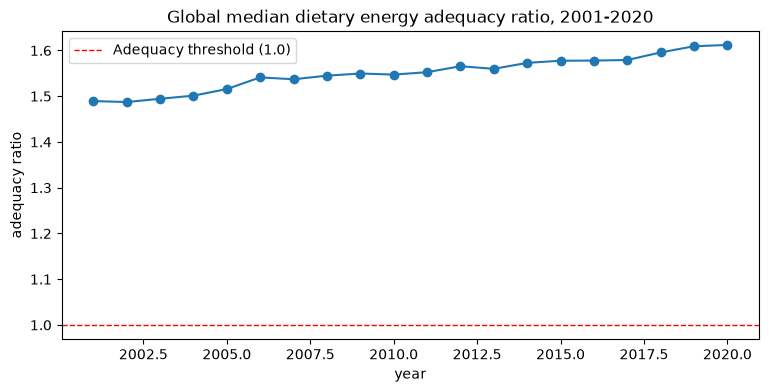

year,median_ratio
i64,f64
2001,1.489338
2002,1.487193
2003,1.494375
2004,1.501122
2005,1.515617
2006,1.541092
2007,1.537013
2008,1.544821
2009,1.549571


In [6]:
global_trend = (
    kpi1_adequacy_ratio
    .group_by("year")
    .agg(pl.col("adequacy_ratio").median().alias("median_ratio"))
    .sort("year")
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(global_trend["year"], global_trend["median_ratio"], marker="o")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Adequacy threshold (1.0)")
ax.set_title("Global median dietary energy adequacy ratio, 2001-2020")
ax.set_xlabel("year")
ax.set_ylabel("adequacy ratio")
ax.legend()
plt.show()

global_trend


## 5. KPI 2 — Countries Below Adequacy Threshold (count per year)

**Definition:** count of countries per year where `adequacy_ratio < 1.0`. A rising
count over 2001–2020 is a direct "worsening global food security" signal.

**Power BI usage:** single KPI card (latest year) + trend line by year.


In [7]:
kpi2_below_threshold = (
    kpi1_adequacy_ratio
    .with_columns((pl.col("adequacy_ratio") < 1.0).alias("below_threshold"))
    .group_by("year")
    .agg(
        pl.col("below_threshold").sum().alias("countries_below_threshold"),
        pl.len().alias("countries_total"),
    )
    .with_columns(
        (100 * pl.col("countries_below_threshold") / pl.col("countries_total"))
        .round(1)
        .alias("pct_below_threshold")
    )
    .sort("year")
)

print(f"Latest year ({YEAR_END}): "
      f"{kpi2_below_threshold.filter(pl.col('year') == YEAR_END)['countries_below_threshold'][0]} "
      f"countries below threshold")
kpi2_below_threshold


Latest year (2020): 0 countries below threshold


year,countries_below_threshold,countries_total,pct_below_threshold
i64,u32,u32,f64
2001,2,171,1.2
2002,2,171,1.2
2003,1,171,0.6
2004,1,171,0.6
2005,1,171,0.6
2006,1,171,0.6
2007,1,170,0.6
2008,1,170,0.6
2009,1,170,0.6


## 6. KPI 3 — Food Security Risk Trend (2001 → 2020 change, ranked)

**Definition:** change in `adequacy_ratio` from 2001 to 2020 per country. Negative
change = worsening food security; positive = improving. This is the direct answer to
"which countries are becoming food insecure."

**Power BI usage:** ranked bar chart (top N decline / top N improvement), or a map
colored by `change`.


In [8]:
first_year = kpi1_adequacy_ratio.filter(pl.col("year") == YEAR_START).select(
    ["area_code", "area", "adequacy_ratio"]
).rename({"adequacy_ratio": "ratio_2001"})

last_year = kpi1_adequacy_ratio.filter(pl.col("year") == YEAR_END).select(
    ["area_code", "area", "adequacy_ratio"]
).rename({"adequacy_ratio": "ratio_2020"})

kpi3_risk_trend = (
    first_year.join(last_year, on=["area_code", "area"], how="inner")
    .with_columns((pl.col("ratio_2020") - pl.col("ratio_2001")).alias("change"))
    .sort("change")
)

print(f"KPI 3 rows (countries with data in both {YEAR_START} and {YEAR_END}): {kpi3_risk_trend.height}")
print("\nTop 10 WORSENING (largest decline in adequacy ratio):")
kpi3_risk_trend.head(10)


KPI 3 rows (countries with data in both 2001 and 2020): 169

Top 10 WORSENING (largest decline in adequacy ratio):


area_code,area,ratio_2001,ratio_2020,change
str,str,f64,f64,f64
"""212""","""Syrian Arab Republic""",1.548647,1.33979,-0.208857
"""236""","""Venezuela (Bolivarian Republic of)""",1.417693,1.26663,-0.151063
"""59""","""Egypt""",1.823562,1.716492,-0.10707
"""159""","""Nigeria""",1.554766,1.451482,-0.103284
"""134""","""Malta""",1.780412,1.67888,-0.101532
"""102""","""Iran (Islamic Republic of)""",1.67214,1.574526,-0.097614
"""250""","""Democratic Republic of the Congo""",1.361715,1.264493,-0.097222
"""124""","""Libya""",1.697928,1.601736,-0.096192
"""202""","""South Africa""",1.587432,1.497831,-0.089601


In [9]:
print("Top 10 IMPROVING (largest increase in adequacy ratio):")
kpi3_risk_trend.sort("change", descending=True).head(10)


Top 10 IMPROVING (largest increase in adequacy ratio):


area_code,area,ratio_2001,ratio_2020,change
str,str,f64,f64,f64
"""1""","""Armenia""",1.1932,1.70882,0.51562
"""235""","""Uzbekistan""",1.260966,1.776258,0.515292
"""52""","""Azerbaijan""",1.283152,1.787814,0.504662
"""7""","""Angola""",0.937914,1.431138,0.493223
"""273""","""Montenegro""",1.373488,1.824395,0.450908
"""272""","""Serbia""",1.431393,1.877743,0.44635
"""208""","""Tajikistan""",1.124352,1.564626,0.440274
"""28""","""Myanmar""",1.153759,1.58199,0.428231
"""141""","""Mongolia""",1.23844,1.653027,0.414587


## 7. KPI 4 — Undernourishment Exposure (population-weighted global average)

**Definition:** global adequacy ratio weighted by each country's population, rather than
a simple median across countries. This answers a different question than KPI 1's median:
"how food-secure is the average *person* worldwide," not "how food-secure is the average
*country*" — large, food-insecure countries (population-wise) move this KPI more than
small ones. Uses `fact_socioeconomic__population` for the population weight.

**Power BI usage:** single trend line alongside KPI 1's median, showing whether the two
diverge (they would diverge if food insecurity is concentrated in populous countries).


In [10]:
pop = conn.execute(f"""
    SELECT area_code, year, value AS population
    FROM {SCHEMA}.fact_socioeconomic__population
    WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
      AND element = 'Total Population - Both sexes'
""").pl()

weighted = (
    kpi1_adequacy_ratio
    .join(pop, on=["area_code", "year"], how="inner")
    .drop_nulls(["adequacy_ratio", "population"])
)

kpi4_weighted_exposure = (
    weighted
    .group_by("year")
    .agg(
        (pl.col("adequacy_ratio") * pl.col("population")).sum().alias("_weighted_sum"),
        pl.col("population").sum().alias("total_population"),
    )
    .with_columns(
        (pl.col("_weighted_sum") / pl.col("total_population")).alias("population_weighted_ratio")
    )
    .drop("_weighted_sum")
    .sort("year")
)

print(f"KPI 4 rows: {kpi4_weighted_exposure.height} "
      f"(countries matched to population: {weighted['area_code'].n_unique()})")
kpi4_weighted_exposure


KPI 4 rows: 20 (countries matched to population: 171)


year,total_population,population_weighted_ratio
i64,f64,f64
2001,7.3349e6,1.493695
2002,7.4235e6,1.492402
2003,7.5115e6,1.492528
2004,7.5997e6,1.496569
2005,7.6887e6,1.503284
2006,7.7866e6,1.510935
2007,7.8659e6,1.525708
2008,7.9578e6,1.539883
2009,8.0515e6,1.54236


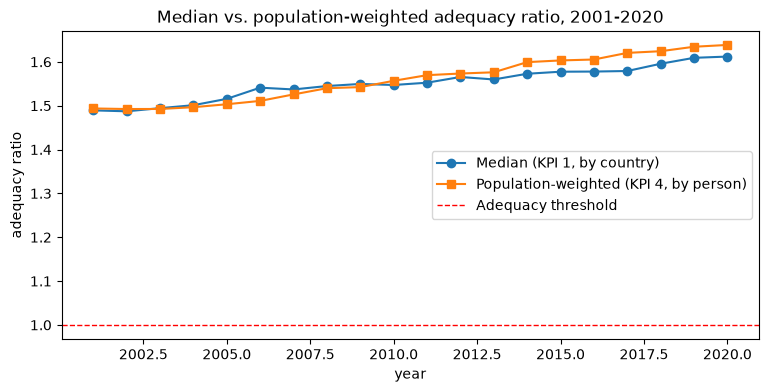

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(global_trend["year"], global_trend["median_ratio"], marker="o", label="Median (KPI 1, by country)")
ax.plot(kpi4_weighted_exposure["year"], kpi4_weighted_exposure["population_weighted_ratio"],
        marker="s", label="Population-weighted (KPI 4, by person)")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Adequacy threshold")
ax.set_title("Median vs. population-weighted adequacy ratio, 2001-2020")
ax.set_xlabel("year")
ax.set_ylabel("adequacy ratio")
ax.legend()
plt.show()


## 8. Findings — final

**Data quality constraints accepted for this deliverable (not fixed, time-boxed):**
- `fact_food_security__data.year` is NULL for 48.34% of rows in the current `marts`
  build (a year-range-string parsing issue diagnosed earlier in this project). All
  queries above filter `WHERE year BETWEEN 2001 AND 2020`, which — because of this
  null rate — is actually filtering on the ~52% of rows where `year` parsed correctly.
  True coverage may be modestly understated as a result. Flagged as a `marts`/staging
  fix for later; not blocking for this deliverable.
- `fact_food_security__data.area_code` mixes real countries with ~14 regional/
  income-group aggregate rows ("World", "Sub-Saharan Africa", "Lower-middle-income
  economies", etc.). Every KPI above explicitly excludes these by inner-joining to
  `fact_socioeconomic__population`, which only contains real countries/territories.
- No single raw indicator in `fact_food_security__data` is both a direct hunger measure
  *and* has full 2001–2020 coverage across all countries. The most direct indicators
  ("Prevalence of moderate/severe food insecurity...") only exist from 2014 onward.
  Given the time constraint, this notebook uses the best available full-scope proxy —
  the dietary energy adequacy ratio — as the primary KPI, and does not attempt to
  backfill or model the pre-2014 gap for the direct indicator.

**What's ready for Power BI, as computed in this notebook:**
- `kpi1_adequacy_ratio` — country-year adequacy ratio
- `kpi2_below_threshold` — countries below threshold, by year
- `kpi3_risk_trend` — 2001→2020 change, ranked
- `kpi4_weighted_exposure` — population-weighted global trend

**Recommended next step (not done here, time-boxed):** these 4 tables should become a
single dbt model (e.g. `marts_bi.food_security_kpis`) so Power BI reads directly from
DuckDB/Postgres rather than from notebook output — this notebook is the reference
implementation for that model's logic.


## Close connection

In [12]:
conn.close()
print("Connection closed")


Connection closed
